In [36]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys

print("All dependencies present")

All dependencies present


In [37]:
#load in dataframe
pd.set_option('display.max_columns', None)

option_print = True
seed_val= 42
file_in = "data/REDUCED_feats_df_cutoff_0.85"

use_cutoff_dirs = 0
if "REDUCED" in file_in:
  use_cutoff_dirs = 1
  print("saving all images to data/cutoff/")

with open(file_in+'.pkl', 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

print(feats_df.shape)
feats_df.head()

saving all images to data/cutoff/
(33770, 42)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,99.395943,97.530229,55.108900,0.958686,100.0,0.0,120.129000,0.564778,0.183575,0.115368,0.879486,0.067138,1,99.998,100.022,38.796,100.0,0.0,9980445.0,45.0,0.0,1.001,0.0,0.979,0.0,2.253881,1.402570,0
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,101.800571,99.451270,56.049556,0.999619,100.0,0.0,120.191190,0.613529,0.226780,0.127976,0.954905,0.046408,1,99.992,100.015,72.380,100.0,0.0,10003140.0,135.0,0.0,1.000,0.0,0.981,0.0,1.325893,1.708478,0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,100.557675,98.103338,29.220831,0.992974,100.0,0.0,133.450130,0.375951,0.220792,0.129524,0.946805,0.050966,1,99.987,100.001,5.766,100.0,0.0,10012320.0,45.0,0.0,1.000,0.0,0.982,0.0,1.273507,1.488691,0
3,0.036364,0.055723,0.088968,0.107719,-0.126763,0.011323,0.809702,1,2,11.png,11,/content/Images3/,1,60,100.278917,96.623433,31.876883,0.998600,100.0,0.0,121.100333,0.640095,0.255338,0.147520,0.879717,0.052488,1,99.996,100.058,126.215,100.0,0.0,10042920.0,135.0,0.0,1.000,0.0,0.985,0.0,1.908427,1.804419,0
4,0.035847,0.078762,0.078230,0.101485,-0.115752,0.010542,0.933894,1,2,12.png,12,/content/Images3/,1,73,103.192973,99.320973,58.915521,0.997630,100.0,0.0,110.340836,0.731391,0.188294,0.110053,0.912808,0.037124,1,99.972,100.015,57.708,100.0,0.0,9882780.0,135.0,0.0,1.000,0.0,0.969,0.0,1.547608,1.687523,0


In [38]:
if use_cutoff_dirs:
    cutoff_dir = "data/cutoff/"
    os.makedirs(cutoff_dir, exist_ok=True)

    cutoff_sub_dir = cutoff_dir + file_in[5:] + "/"
    os.makedirs(cutoff_sub_dir, exist_ok=True)

    specific_file_dir = cutoff_sub_dir + "K_MeansClustering/"
    os.makedirs(specific_file_dir, exist_ok=True)

else:
    output_dir = "data/output_images/"
    os.makedirs(output_dir, exist_ok=True)

    output_sub_dir = output_dir + file_in[5:] + "/"
    os.makedirs(output_sub_dir, exist_ok=True)

    specific_file_dir = output_sub_dir + "K_MeansClustering/"
    os.makedirs(specific_file_dir, exist_ok=True)

In [39]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:-3]])) # 14th column - third from last (exclusive)
print(feat_array_scaled.shape)

# Applying PCA function on training and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(feat_array_scaled)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

feats_df["pc1"] = pca_data[:,0]
feats_df["pc2"] = pca_data[:,1]

# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)
print("\nPCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

print("PC1:")
for feat in top_features["PC1"]:
    print(f"----{feats_df.columns[feat + 13]}")
print("PC2A:")
for feat in top_features["PC2"]:
    print(f"----{feats_df.columns[feat + 13]}")

(33770, 26)
[0.32704176 0.15427178]

PCA Loadings:
             PC1           PC2
0   2.268489e-01  3.055834e-01
1   3.897351e-02 -3.950763e-02
2   1.200744e-02 -5.846903e-02
3   3.184078e-01  6.235782e-02
4   8.073129e-02  4.321609e-01
5   1.608017e-01 -2.644381e-02
6   0.000000e+00 -2.168404e-19
7  -3.016172e-01 -7.307653e-02
8   1.817753e-01 -2.812058e-01
9   2.792219e-01  3.314561e-02
10  3.262133e-01  1.491352e-01
11 -2.860960e-01  4.752869e-02
12  2.844067e-01 -7.482056e-02
13  1.067826e-01 -2.600590e-01
14 -2.010070e-02  5.186494e-02
15  1.886094e-02 -4.071994e-02
16  2.772743e-01  1.560294e-01
17  1.851618e-01  1.811630e-01
18 -2.168741e-30  6.647652e-26
19  3.240097e-02  3.335636e-01
20 -1.789336e-01 -6.651029e-03
21  1.689586e-01 -1.937704e-01
22  1.293767e-01 -2.887170e-01
23  1.595954e-01 -3.420247e-01
24 -2.683238e-01 -8.340378e-02
25  2.069685e-01 -3.307267e-01

Top Contributing Features per Principal Component:
{'PC1': [10, 3, 7], 'PC2': [4, 23, 19]}
PC1:
----Round_std
-

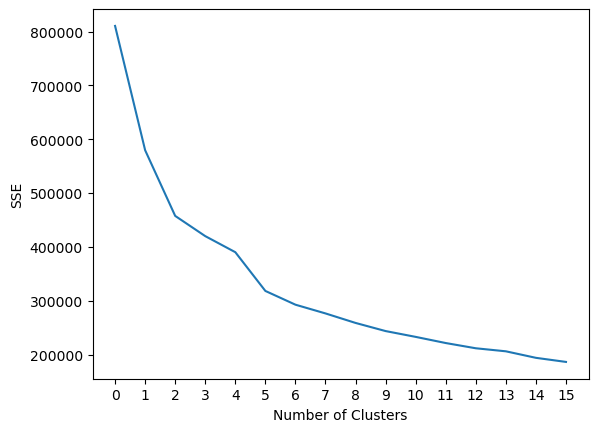

In [40]:
# K_means clustering

from sklearn.cluster import KMeans

#Find optimum number of clusters
sse = [] #SUM OF SQUARED ERROR
for k in range(1,17):
    km = KMeans(n_clusters=k, random_state=seed_val)
    km.fit(feat_array_scaled)
    sse.append(km.inertia_)

fig, ax = plt.subplots()
ax.set(xlabel = "Number of Clusters", ylabel = "SSE", xticks = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

ax.plot(sse)

plt.show()

In [41]:
num_clusters = 6
file_out = file_in + "_KM_classes_" + str(num_clusters) + "_s" + str(seed_val) + ".pkl"

In [42]:
# K_means clustering
from sklearn.cluster import KMeans

cluster_dicts = {}

for c in range(num_clusters):
    print(c)
    working_df = feats_df
    km = KMeans(n_clusters = num_clusters, init='k-means++', n_init=50, max_iter=300,
                tol=0.0001, random_state=seed_val)
    clusters = km.fit(feat_array_scaled)
    working_df["cluster"] = clusters.labels_
    # create entry in dictionary
    cluster_dicts[str(c)] = working_df

0
1
2
3
4
5


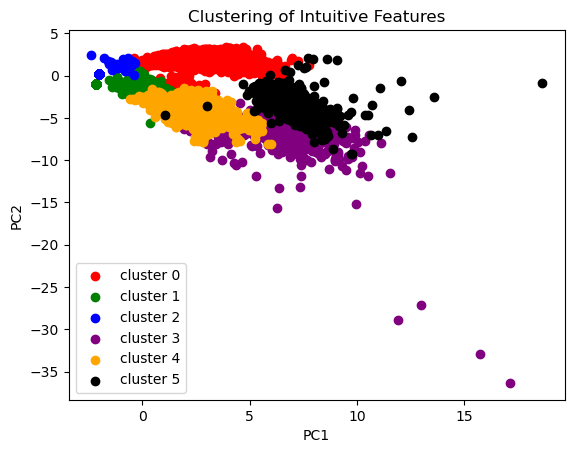

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,99.395943,97.530229,55.108900,0.958686,100.0,0.0,120.129000,0.564778,0.183575,0.115368,0.879486,0.067138,1,99.998,100.022,38.796,100.0,0.0,9980445.0,45.0,0.0,1.001,0.0,0.979,0.0,2.253881,1.402570,0
1,0.034475,0.059956,0.080798,0.100370,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,101.800571,99.451270,56.049556,0.999619,100.0,0.0,120.191190,0.613529,0.226780,0.127976,0.954905,0.046408,1,99.992,100.015,72.380,100.0,0.0,10003140.0,135.0,0.0,1.000,0.0,0.981,0.0,1.325893,1.708478,0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,100.557675,98.103338,29.220831,0.992974,100.0,0.0,133.450130,0.375951,0.220792,0.129524,0.946805,0.050966,1,99.987,100.001,5.766,100.0,0.0,10012320.0,45.0,0.0,1.000,0.0,0.982,0.0,1.273507,1.488691,0
3,0.036364,0.055723,0.088968,0.107719,-0.126763,0.011323,0.809702,1,2,11.png,11,/content/Images3/,1,60,100.278917,96.623433,31.876883,0.998600,100.0,0.0,121.100333,0.640095,0.255338,0.147520,0.879717,0.052488,1,99.996,100.058,126.215,100.0,0.0,10042920.0,135.0,0.0,1.000,0.0,0.985,0.0,1.908427,1.804419,0
4,0.035847,0.078762,0.078230,0.101485,-0.115752,0.010542,0.933894,1,2,12.png,12,/content/Images3/,1,73,103.192973,99.320973,58.915521,0.997630,100.0,0.0,110.340836,0.731391,0.188294,0.110053,0.912808,0.037124,1,99.972,100.015,57.708,100.0,0.0,9882780.0,135.0,0.0,1.000,0.0,0.969,0.0,1.547608,1.687523,0


In [43]:
clusters = np.unique(np.array(feats_df["cluster"])) # list of unique clusters
cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = feats_df[feats_df["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)

# plot the data
fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink", "yellow", "brown", 'gray', 'cyan']

for j in clusters:
  df = cluster_dfs[j]
  ax.scatter(df["pc1"], df["pc2"], c = colors[j], label = "cluster " + str(j))

leg = ax.legend(loc="lower left")
ax.set(xlabel = "PC1", ylabel = "PC2", title = "Clustering of Intuitive Features")

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "KMeansClustering_of_Intuitive_Features_cl" + str(num_clusters) + ".png", dpi = 300)
plt.show()

feats_df.head()

In [44]:
# add pc1, pc2, cluster columns
feats_df.to_pickle(file_out)
print(feats_df.shape)

(33770, 42)


In [45]:
# print image or random images for a given column in the dataframe

def show_image(image_num = None, num_random_images = None, df = feats_df):
  if image_num is not None:
    image_path = df["dir"][image_num] + df["path"][image_num]

    image = Image.open(str(image_path[1:]))

    plt.figure()
    plt.imshow(image, cmap = "YlOrRd", vmin = 0, vmax = 255)
    plt.show()
    print(image_path)

  if num_random_images is not None:
    random_indices = np.random.randint(0, df.shape[0], num_random_images)
    print(random_indices)
    for i in random_indices:
      image_path = df["dir"][i] + df["path"][i]


      image = Image.open(str(image_path[1:]))

      # plt.figure()
      # plt.imshow(image, cmap = "YlOrRd", vmin = 0, vmax = 255)
      # plt.show()
      # print(image_path)

def col_to_print_func(col_to_print = None, num_random_images = None, image_num = None):
  groups = feats_df[col_to_print].unique()
  groups.sort()
  groups = groups.tolist()

  for group in groups:
    print(f"Images from {col_to_print} = {group}")
    cluster_df = feats_df[feats_df[col_to_print] == group].reset_index(drop=True)
    show_image(num_random_images = num_random_images, image_num = image_num, df=cluster_df)

col_to_print_func(col_to_print = "cluster", num_random_images=3)

Images from cluster = 0
[6491 8473 2955]
Images from cluster = 1
[10088  3363   746]
Images from cluster = 2
[8150 7184 5196]
Images from cluster = 3
[639  56 145]
Images from cluster = 4
[593 313 113]
Images from cluster = 5
[205 736 253]


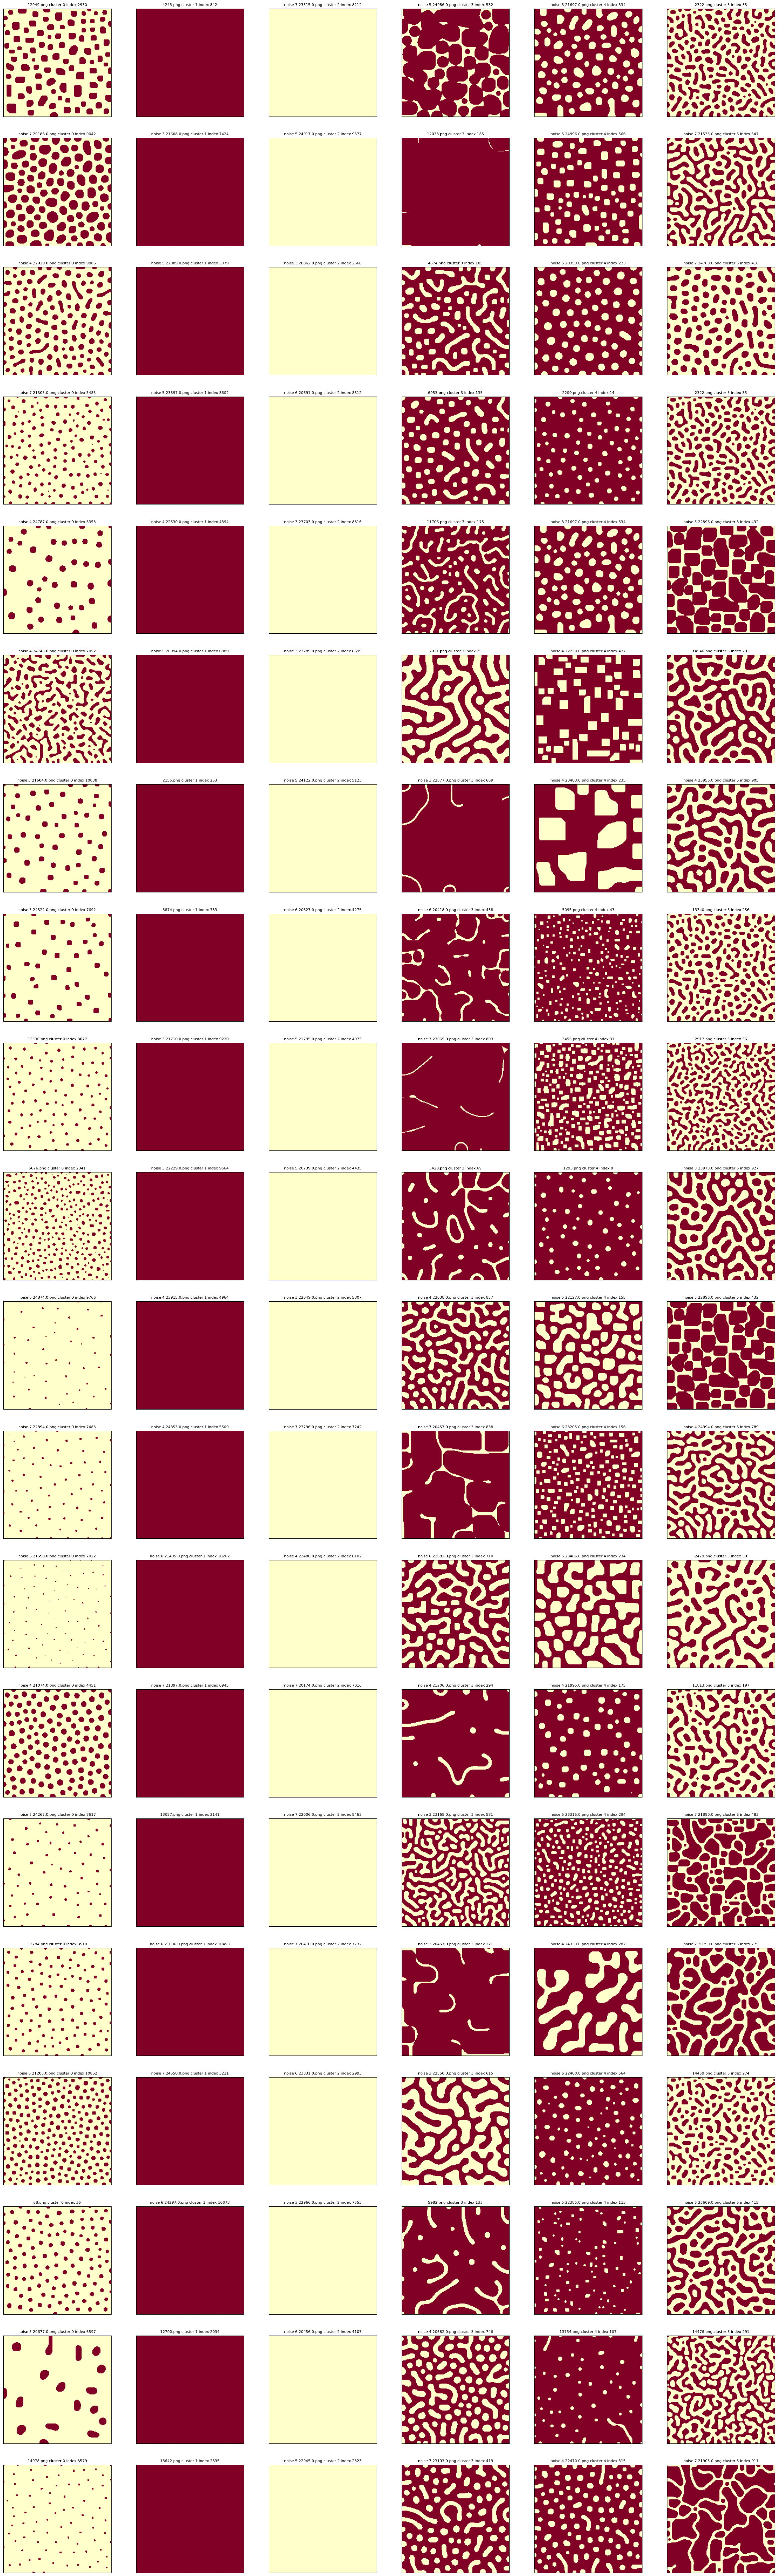

In [46]:
num_imgs = 20

fig, ax = plt.subplots(num_imgs, len(cluster_dfs))

for i in range(num_imgs):
  for j in range(len(cluster_dfs)):
    df = cluster_dfs[j]
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path[1:]))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 8)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)

fig.set_figwidth(5*len(cluster_dfs))
fig.set_figheight(5 * num_imgs)

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "KMeansClustering_ImagesPerCluster_cl" + str(num_clusters) + ".png", dpi = 300)
plt.show()